In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
warnings.filterwarnings('ignore')    #hiding warnings for clear outputs

In [3]:
df = pd.read_csv('preprocessed_data.csv')    #reading the data

In [4]:
df.head()

,Offence,Year,Number,Rate,State,Sex
0,Homicide and related offences,2008,247.0,8.2,New South Wales,Male
1,Acts intended to cause injury,2008,23080.0,765.5,New South Wales,Male
2,Sexual assault and related offences,2008,1402.0,46.5,New South Wales,Male
3,Dangerous/negligent acts,2008,116.0,3.8,New South Wales,Male
4,Abduction/harassment,2008,698.0,23.2,New South Wales,Male


In [6]:
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")       #rows and columns of our clean dataset

   Rows: 5575
   Columns: 6


In [11]:
print(df.dtypes)       #columns and their data type

Offence     object
Year         int64
Number     float64
Rate       float64
State       object
Sex         object
dtype: object


In [14]:
print(df.isnull().sum())  #checking if null still exists

Offence    0
Year       0
Number     0
Rate       0
State      0
Sex        0
dtype: int64


In [15]:
for col in df.columns:
    print(f"   {col}: {df[col].nunique()} unique values") #checking for number of unique values in our features

   Offence: 16 unique values
   Year: 17 unique values
   Number: 2671 unique values
   Rate: 2401 unique values
   State: 8 unique values
   Sex: 3 unique values


In [16]:
#Now lets look at the type of offences

for i, offence in enumerate(df['Offence'].unique(), 1):
    print(f"   {i}. {offence}")

   1. Homicide and related offences
   2. Acts intended to cause injury
   3. Sexual assault and related offences
   4. Dangerous/negligent acts
   5. Abduction/harassment
   6. Robbery/extortion
   7. Unlawful entry with intent
   8. Theft
   9. Fraud/deception
   10. Illicit drug offences
   11. Weapons/explosives
   12. Property damage and environmental pollution
   13. Public order offences
   14. Offences against justice
   15. Miscellaneous offences
   16. Fare evasion


In [17]:
# Lets have a look at the states covered in Australia

for state in df['State'].unique():
    print(f"   - {state}")

   - New South Wales
   - Victoria
   - Queensland
   - South Australia
   - Western Australia
   - Tasmania
   - Northern Territory
   - Australian Capital Territory


In [19]:
#this dataset contains data from several years. lets look at those years

print(f"\n Year range: {df['Year'].min()} to {df['Year'].max()}")
print(f"   Total years covered: {df['Year'].nunique()} years")


 Year range: 2008 to 2024
   Total years covered: 17 years


Now lets do further data cleaning to make our data more suitable for EDA.

In [21]:
#In the sex column, we have the following categories.


print("\n Sex categories:", df['Sex'].unique().tolist())


 Sex categories: ['Male', 'Female', 'Unknown']


In [22]:
#Since the sex category contains "unknown" as well, so we remove those rows as it doesnt help us understand any gender based offences.

df_clean = df[df['Sex'] != 'Unknown'].copy()

In [23]:
print(f"   Rows removed: {len(df) - len(df_clean)}")

   Rows removed: 1405


In [24]:
df_clean.shape

(4170, 6)

In [27]:
# Lets look at the outliers


#For outliers, lets calculate the IQR (Interquartile Range)

Q1 = df_clean['Rate'].quantile(0.25)   # 25th percentile
Q3 = df_clean['Rate'].quantile(0.75)   # 75th percentile
IQR = Q3 - Q1                          # Interquartile range

# Defining outlier boundaries

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"   Q1 (25th percentile): {Q1:.2f}")
print(f"   Q3 (75th percentile): {Q3:.2f}")
print(f"   IQR: {IQR:.2f}")
print(f"   Lower bound: {lower_bound:.2f}")
print(f"   Upper bound: {upper_bound:.2f}")

# Total count of outliers
outliers = df_clean[(df_clean['Rate'] < lower_bound) | (df_clean['Rate'] > upper_bound)]
print(f"\n   Total outliers found: {len(outliers)}")
print(f"  It represents {(len(outliers)/len(df_clean)*100):.1f}% of the data")

   Q1 (25th percentile): 11.20
   Q3 (75th percentile): 155.38
   IQR: 144.18
   Lower bound: -205.06
   Upper bound: 371.64

   Total outliers found: 415
  It represents 10.0% of the data



   Top 10 highest rate outliers:
                      Offence  Year              State  Sex   Rate
Acts intended to cause injury  2024 Northern Territory Male 2959.6
        Public order offences  2017 Northern Territory Male 2846.8
        Public order offences  2009 Northern Territory Male 2716.7
        Public order offences  2013 Northern Territory Male 2648.9
        Public order offences  2016 Northern Territory Male 2633.5
Acts intended to cause injury  2022 Northern Territory Male 2615.0
        Public order offences  2015 Northern Territory Male 2572.4
Acts intended to cause injury  2013 Northern Territory Male 2569.1
        Public order offences  2008 Northern Territory Male 2526.6
Acts intended to cause injury  2012 Northern Territory Male 2525.9


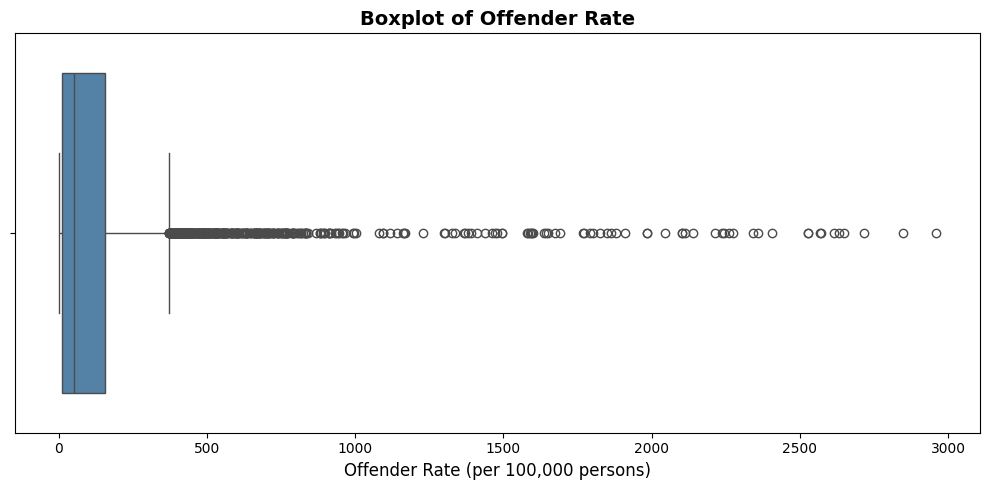

In [28]:

# Lets look at the top 10 highest outliers
print("\n   Top 10 highest rate outliers:")
print(outliers.sort_values('Rate', ascending=False)[
    ['Offence', 'Year', 'State', 'Sex', 'Rate']
].head(10).to_string(index=False))

# Lets visualise outliers using a boxplot
plt.figure(figsize=(10, 5))


sns.boxplot(x=df_clean['Rate'], color='steelblue')

plt.title('Boxplot of Offender Rate', fontsize=14, fontweight='bold')
plt.xlabel('Offender Rate (per 100,000 persons)', fontsize=12)
plt.tight_layout()
plt.show()

Exploratory Data Analysis


 Average Offender Rate by Offence Type:
                                    Offence  Average Rate
                      Public order offences    483.277574
              Acts intended to cause injury    479.850000
                      Illicit drug offences    365.613235
                                      Theft    200.521691
                   Offences against justice    158.355882
                               Fare evasion    122.177778
                     Miscellaneous offences     87.536397
Property damage and environmental pollution     83.481250
                 Unlawful entry with intent     81.665074
                         Weapons/explosives     76.152574
                            Fraud/deception     44.495221
        Sexual assault and related offences     39.769485
                       Abduction/harassment     23.463971
                          Robbery/extortion     22.123162
                   Dangerous/negligent acts      9.798529
              Homicide and rela

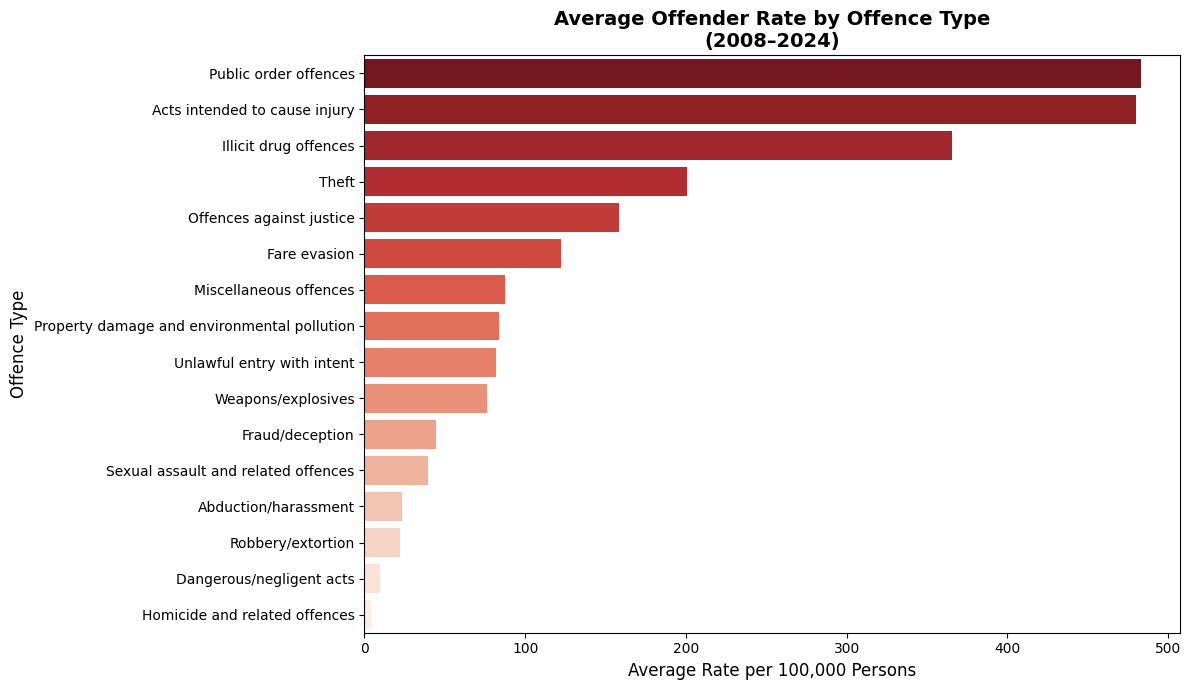

In [30]:

# Question: Which offence type, location, or sex requires focused intervention?


# Lets group by Offence and then calculate the mean (average) rate
# This tells us which is the most prevalent offence type

top_offences = (
    df_clean.groupby('Offence')['Rate']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
top_offences.columns = ['Offence', 'Average Rate']

print("\n Average Offender Rate by Offence Type:")
print(top_offences.to_string(index=False))

#Plotting for easy visualization
plt.figure(figsize=(12, 7))


sns.barplot(
    data=top_offences,
    x='Average Rate',
    y='Offence',
    palette='Reds_r'      # Red gradient and the more darker color means higher rate
)

plt.title('Average Offender Rate by Offence Type\n(2008–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Average Rate per 100,000 Persons', fontsize=12)
plt.ylabel('Offence Type', fontsize=12)
plt.tight_layout()

plt.show()


 Average Offender Rate by State:
                       State  Average Rate
          Northern Territory    333.287843
             South Australia    164.778571
                    Tasmania    151.961765
                  Queensland    129.185150
           Western Australia    116.125490
             New South Wales    112.339139
                    Victoria     90.487594
Australian Capital Territory     53.571961


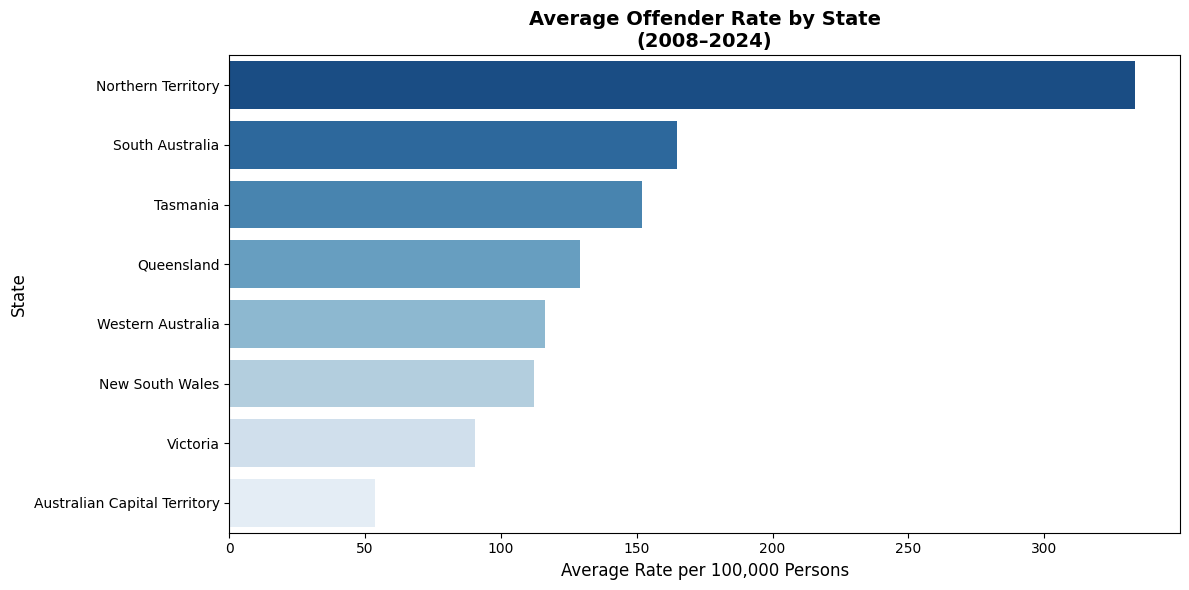

In [32]:

# Question: Which state has the most Offender Rates?
# Lets group by State and calculate average rate


state_rates = (
    df_clean.groupby('State')['Rate']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
state_rates.columns = ['State', 'Average Rate']

print("\n Average Offender Rate by State:")
print(state_rates.to_string(index=False))

#Plotting
plt.figure(figsize=(12, 6))

sns.barplot(
    data=state_rates,
    x='Average Rate',
    y='State',
    palette='Blues_r'
)

plt.title('Average Offender Rate by State\n(2008–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Average Rate per 100,000 Persons', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.tight_layout()
plt.show()



 Average Offender Rate by Sex:
   Sex  Average Rate
Female     70.369736
  Male    216.699904


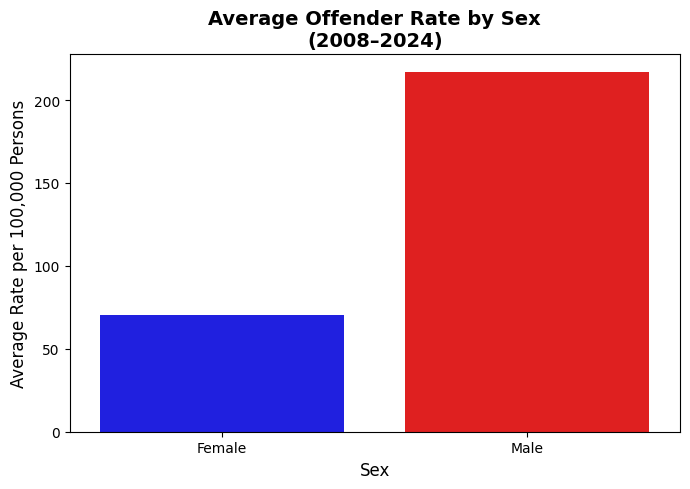

In [34]:
# Question: Offender Rate by Sex?
# Lets compare average offender rates between Male and Female


sex_rates = (
    df_clean.groupby('Sex')['Rate']
    .mean()
    .reset_index()
)
sex_rates.columns = ['Sex', 'Average Rate']

print("\n Average Offender Rate by Sex:")
print(sex_rates.to_string(index=False))

# Plotting
plt.figure(figsize=(7, 5))

sns.barplot(
    data=sex_rates,
    x='Sex',
    y='Average Rate',
    palette=['blue', 'red']
)

plt.title('Average Offender Rate by Sex\n(2008–2024)', fontsize=14, fontweight='bold')
plt.xlabel('Sex', fontsize=12)
plt.ylabel('Average Rate per 100,000 Persons', fontsize=12)
plt.tight_layout()
plt.show()



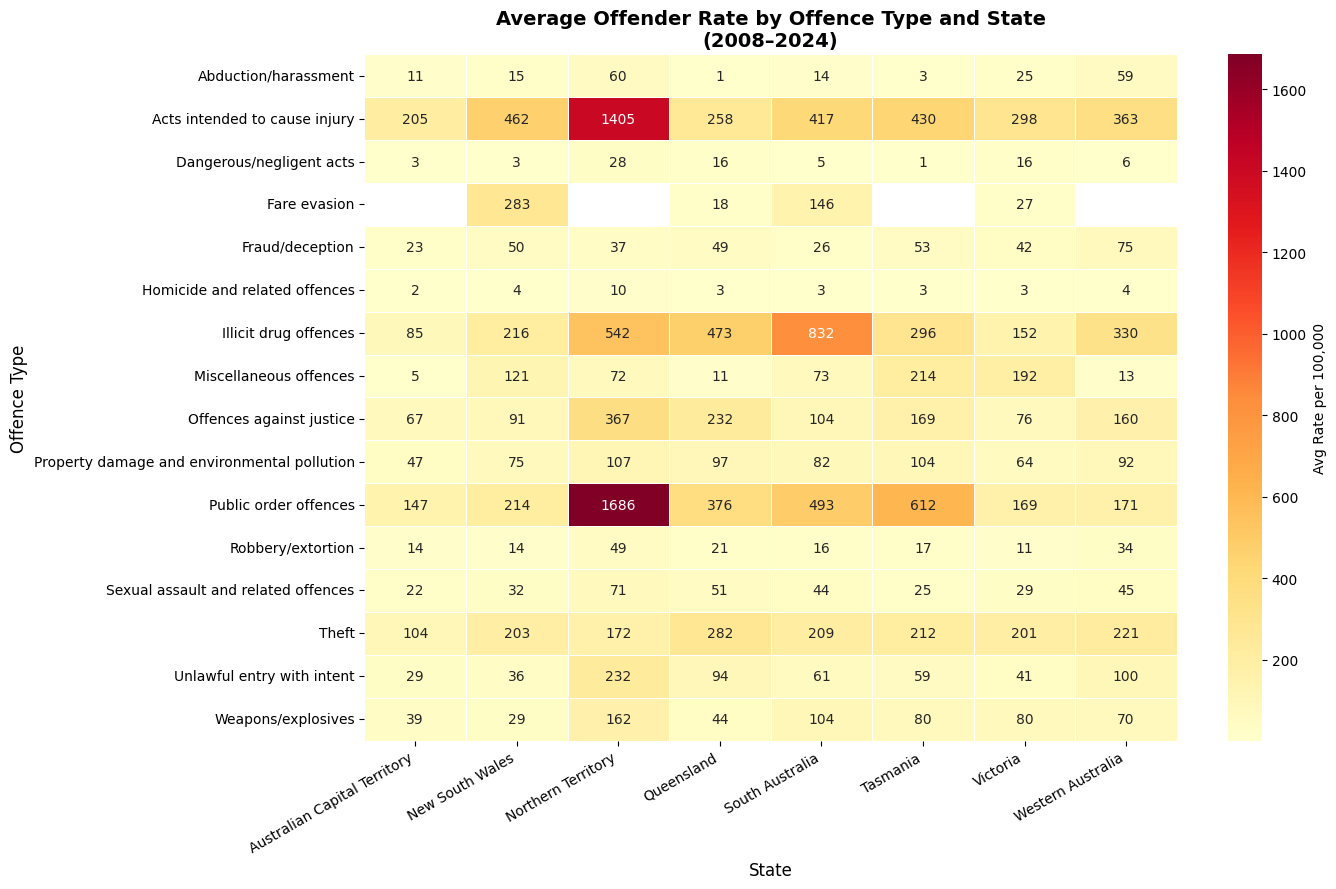

In [43]:
# Lets visualize further with heatmap

heatmap_data = df_clean.pivot_table(
    index='Offence',
    columns='State',                 #relation between offence and state
    values='Rate',
    aggfunc='mean'
)

plt.figure(figsize=(14, 9))

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    annot=True,            #also display data
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Avg Rate per 100,000'}
)

plt.title('Average Offender Rate by Offence Type and State\n(2008–2024)',
          fontsize=14, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Offence Type', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

plt.show()


In [37]:
# Finding the top offences in each states (most concerning)
#This helps in finding out where and which offence needs intervention

top_offence_per_state = (
    df_clean.groupby(['State', 'Offence'])['Rate']
    .mean()
    .reset_index()
    .sort_values(['State', 'Rate'], ascending=[True, False])
)

#Lets filter out the top 1 offence
top1_offence_per_state = top_offence_per_state.groupby('State').first().reset_index()
top1_offence_per_state.columns = ['State', 'Top Offence', 'Average Rate']

print("\n Highest Rate Offence per state :")
print(top1_offence_per_state.to_string(index=False))



 Highest Rate Offence per state :
                       State                   Top Offence  Average Rate
Australian Capital Territory Acts intended to cause injury    205.282353
             New South Wales Acts intended to cause injury    462.100000
          Northern Territory         Public order offences   1685.664706
                  Queensland         Illicit drug offences    472.679412
             South Australia         Illicit drug offences    831.858824
                    Tasmania         Public order offences    611.835294
                    Victoria Acts intended to cause injury    298.288235
           Western Australia Acts intended to cause injury    362.888235



 Top 5 Offences for Males:
                      Offence       Rate
Acts intended to cause injury 747.167647
        Public order offences 690.723529
        Illicit drug offences 554.272059
     Offences against justice 247.248529
                        Theft 240.282353

 Top 5 Offences for Females:
                      Offence       Rate
        Public order offences 275.831618
Acts intended to cause injury 212.532353
        Illicit drug offences 176.954412
                        Theft 160.761029
     Offences against justice  69.463235


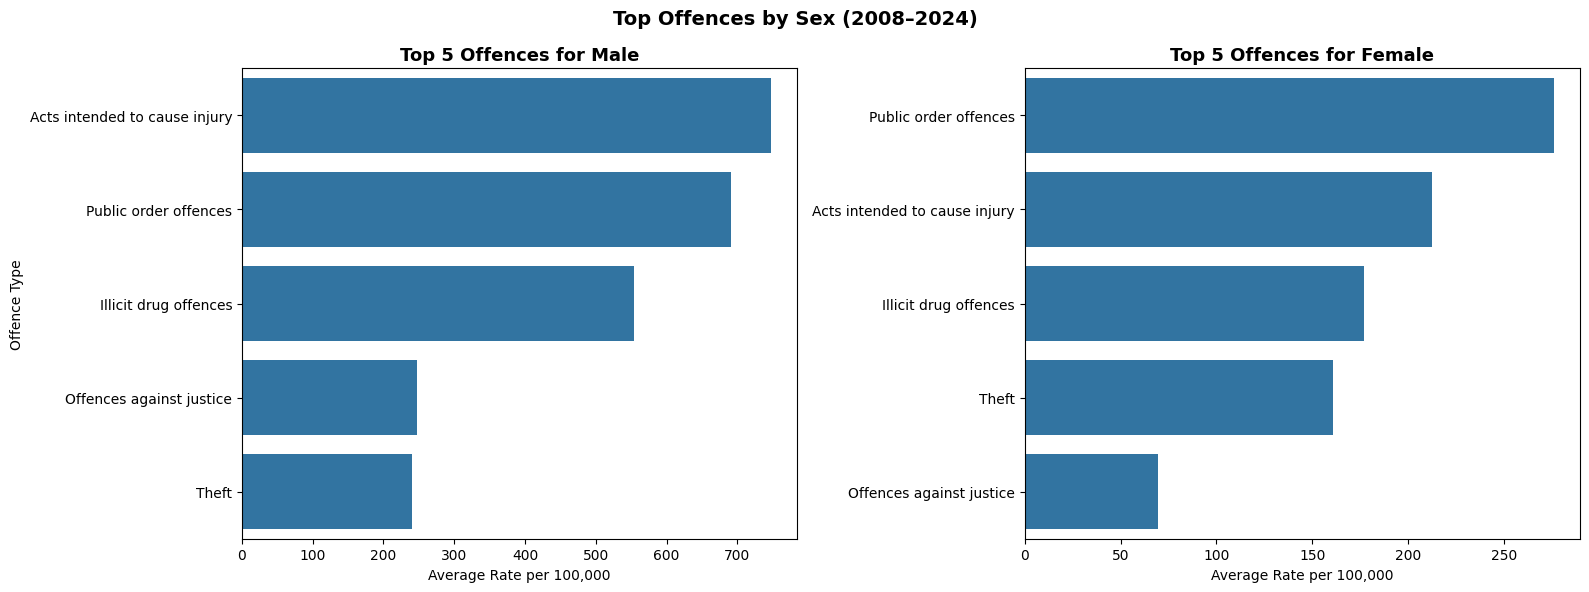

In [39]:

# Lets compare what offences Males and Females commit most

# Calculating the average rate per sex per offence
sex_offence = (
    df_clean.groupby(['Sex', 'Offence'])['Rate'] #grouping by sex and offence with the average rate
    .mean()
    .reset_index()
)

#Separating into male and female
male_top = (sex_offence[sex_offence['Sex'] == 'Male']
            .sort_values('Rate', ascending=False).head(5))
female_top = (sex_offence[sex_offence['Sex'] == 'Female']
              .sort_values('Rate', ascending=False).head(5))

print("\n Top 5 Offences for Males:")
print(male_top[['Offence', 'Rate']].to_string(index=False))

print("\n Top 5 Offences for Females:")
print(female_top[['Offence', 'Rate']].to_string(index=False))

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Male
sns.barplot(
    data=male_top,
    x='Rate', y='Offence',
    ax=axes[0]
)
axes[0].set_title('Top 5 Offences for Male', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Rate per 100,000')
axes[0].set_ylabel('Offence Type')

# Female
sns.barplot(
    data=female_top,
    x='Rate', y='Offence',
    ax=axes[1]
)
axes[1].set_title('Top 5 Offences for Female', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Rate per 100,000')
axes[1].set_ylabel('')

plt.suptitle('Top Offences by Sex (2008–2024)', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()


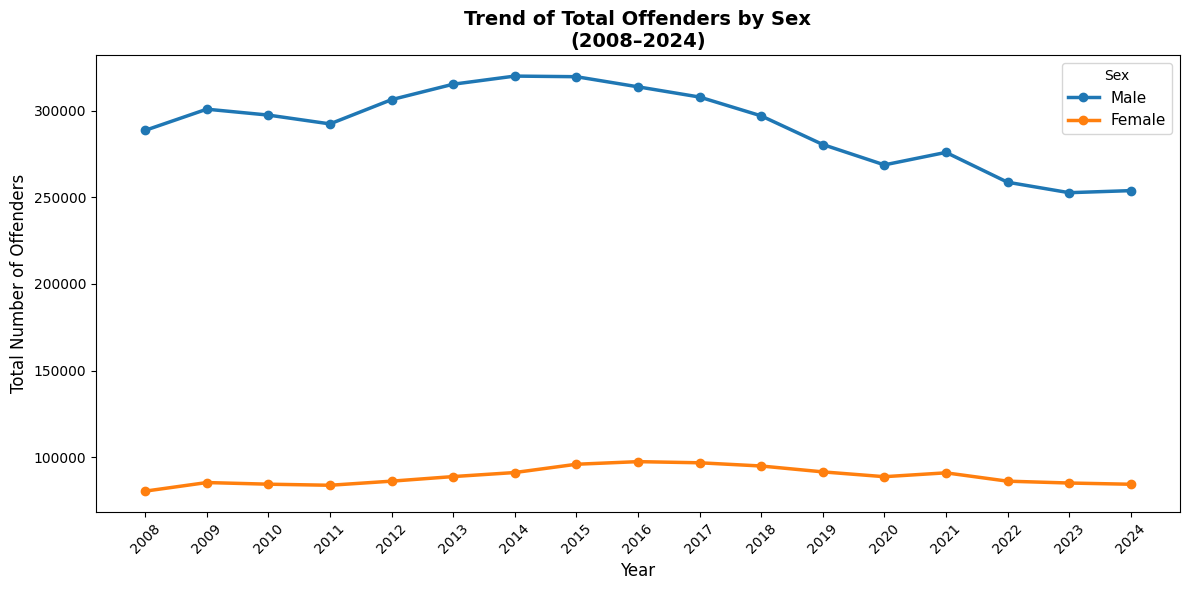

In [44]:
# Lets look at the overall trend of offence rate by Sex over the years


yearly_sex = (
    df_clean.groupby(['Year', 'Sex'])['Number']
    .sum()                  # Adding up all offenders for each year and sex
    .reset_index()
)

# Plotting
plt.figure(figsize=(12, 6))

#drawing the line chart
for sex in ['Male', 'Female']:


    data = yearly_sex[yearly_sex['Sex'] == sex]

    # Plotting the line
    plt.plot(
        data['Year'],          #x-axis=year
        data['Number'],
        marker='o',
        linewidth=2.5,
        markersize=6,
        label=sex
    )

plt.title('Trend of Total Offenders by Sex\n(2008–2024)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Number of Offenders', fontsize=12)
plt.legend(title='Sex', fontsize=11)
plt.xticks(yearly_sex['Year'].unique(), rotation=45) #displaying every year
plt.tight_layout()

plt.show()